# Value at Risk and Expected Shortfall Analysis using real financial data

Value at Risk (VaR) is the standard risk measure used by banks, hedge funds, and regulators worldwide. In this project, three different methods of calculating VaR are presented and compared, namely:

- Historical Simulation Method

- Parametric Method

- Monte Carlo Method

Each method relies on different statistical assumptions on the data, therefore the yielded results are different for each one. In this notebook, the results for each of those methods will be derived, compared and conclusion will be drawn based on the differences. Furthermore, the project also extends the analysis to Expected Shortfall, comparing its value with the one obtained for VaR, to showcase the severity of losses beyond the VaR threshold.

## Value at Risk Definition

Value at Risk (VaR) is describing the amount of loss on an investment, given a time horizon and confidence level. For example, if it is stated that the 99% VaR of investment over a specific time frame is 5%, this means that with a confidence of 99%, not more than 5% of the investment will be lost. This also means that there is a probability of 1%, that more than 5% of the investment will be lost during this time frame.

## Daily log returns

In this project, daily log returns will be used for the following statistical analysis, instead of raw stock prices. The reason behind this choice lies on the mathematical convenience behind using logarithms, as well as the non-dimensional nature of log returns. A daily log return can be mathematically defined as follows:

 $ \begin{equation}  r_{t} = \log \left(\frac{P_{t}}{P_{t-1}} \right) \end{equation}$

The numerator $P_{t}$ stands for the stock price on a specific day, while the denominator $P_{t-1}$ for the stock price the previous day.

## Expected Shortfall Definition

Although VaR gives information about the threshold of the loss, it carries no information about the amount of loss in the worst $(1-CL)\%$ days. For this reason, the quantity of Expected Shortfall (Conditional Value at Risk - CVaR) is defined as the average loss percentage in the worst $(1-CL)\%$ days. It can be also formulated mathematically, using the following conditional probability formula:

$\begin{equation}  ES_{99\%} = - \mathbb{E}\left[ r | r < - VaR_{99\%}\right]\end{equation}$

## Value at Risk Analysis

As a first step in the analysis, we will download financial data from the Apple stock (AAPL) from 2018 to 2023. We will take a look in the first lines and then we will plot the distribution of the daily log returns, extracting the information about the mean and the standard deviation of the distribution. Additionally, a Gaussian distribution is plotted in the same figure, with a mean value and a standard deviation equal to the ones of the daily log returns distribution, to allow for a comparison between the shape of the two distributions.

In [4]:
import yfinance as yf
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import VaR_utils as VaR

In [5]:
returns = VaR.get_returns("AAPL","2018-01-01", "2023-12-31")
print(f"Number of trading days: {len(returns)}")
print(f"First few returns:\n {returns.head()}")

Number of trading days: 1508
First few returns:
 Date
2018-01-03   -0.000174
2018-01-04    0.004634
2018-01-05    0.011321
2018-01-08   -0.003721
2018-01-09   -0.000115
Name: AAPL, dtype: float64


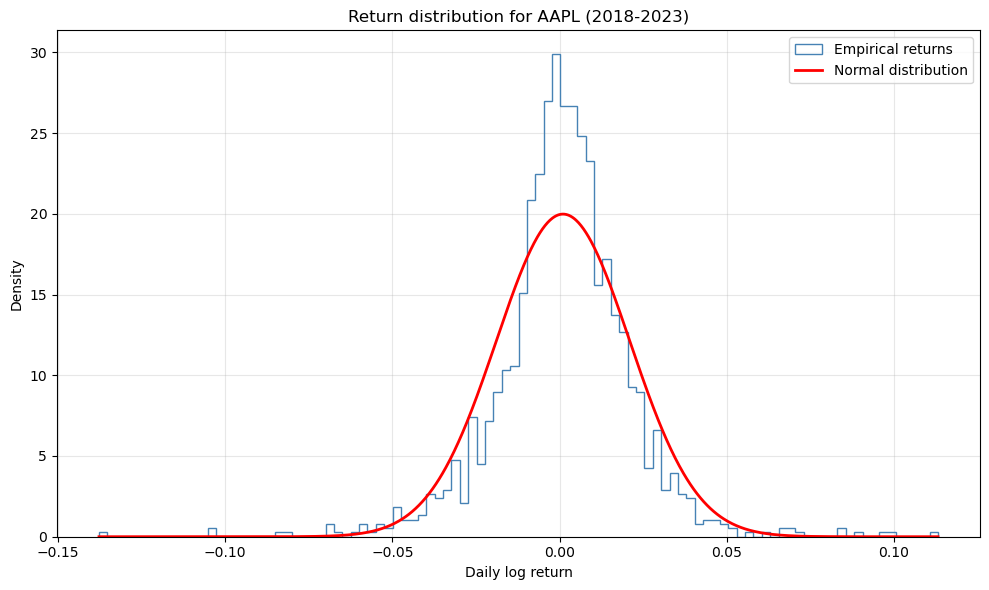

Mean daily return: 0.001030
Standard deviation of daily returns: 0.019965
Skewness: -0.2447
Kurtosis: 5.0799


In [6]:
VaR.plot_returns(returns,"AAPL")

As it can be seen from the above figure, the distribution of daily log returns seems to be diverging to a small extent from a Gaussian distribution. The first sign of divergence is reported in the kurtosis of the daily log distribution, which is found to be 5.0799, while a Gaussian distribution has a kurtosis of around 3. Furthermore, as reported from the skewness, the daily log return distribution seems to be slightly asymmetric on the left, showing some longer tails that are not predicted by a Gaussian distribution. Finally, the peak around the mean seems to be way sharper for the daily log return distribution that the one predicted from a Gaussian distribution, meaning that more values are around the mean than predicted.

As a next step we will compute the VaR using the **Historical Simulation Method**. This method is the simplest of the three as it does not rely on an assumption for the distribution of the daily returns, extracting the VaR as the $(100-CL)\%$ percentile purely based on the data distribution:

In [8]:
var_hist = VaR.var_historical(returns,0.99)

print(f"Historical Simulation VaR (99%): {var_hist:4f}")
print(f"This means that on 99% of days, the loss will not exceed {var_hist*100:.2f}%")

Historical Simulation VaR (99%): 0.053730
This means that on 99% of days, the loss will not exceed 5.37%


**Conclusion**: According to the result derived using the **Historical Simulation Method**, the value of VaR is $5.37\%$. The meaning of this number is that in $99%$ of the days, the loss in the investment will not exceed $5.37\%$.

Next up, we will use the **Parametric Method** to estimate VaR. In this method, no simulation is required. The assumption that is made is that the data are following a Gaussian distribution, so VaR can analytically be proven to depend on the mean value, standard deviation and the $z_{0.01}$ percentile of a Standard Normal Distribution, based on the following formula:

$ \begin{equation} VaR_{99\%} = - \left( \mu + \sigma \cdot z_{0.01} \right ) \end{equation}$ 

In [9]:
var_par = VaR.var_parametric(returns,0.99)

print(f"Parametric VaR (99%): {var_par:.4f}")
print(f"This means that on 99% of the days, the loss will not exceed {var_par*100:2f}%")
print(f"The difference between the historical simulation: {(var_hist-var_par)*100:2f}%")

Parametric VaR (99%): 0.0454
This means that on 99% of the days, the loss will not exceed 4.541599%
The difference between the historical simulation: 0.831444%


**Conclusion**: According to the result derived using the **Parametric Method**, the value of VaR is $4.54\%$. The meaning of this number is that in $99%$ of the days, the loss in the investment will not exceed $4.54\%$. By comparing the values given from the two methods, it can be observed that there is a difference of $0.831444\%$, with the **Historical Distribution Method** predicting a higher VaR value. This is absolutely justified according to the previous figure, since the **Parametric Method** is relying on the assumption that the data will be distributed according to a Gaussian distribution. However, the previous figure has shown to not take into account the long tails of the daily return distribution, meaning it is underestimating the frequency of extreme losses.

The next method that we will use is the **Monte Carlo Method**. As the name suggests, this method is using the information about the mean and the standard deviation of the data, drawing a requested amount of numbers following a Gaussian distribution with this mean and standard deviation, computing the loss at the desired percentile of the simulated distribution. As in the **Parametric Method**, the assumption that the data are following a Gaussian distribution is also present here.

In [10]:
var_mc = VaR.var_montecarlo(returns,0.99,100000)

print(f"Monte Carlo VaR (99%): {var_mc:.4f}")
print(f"This means that 99% of the days, the loss will not exceed {100*var_mc:.2f}%")
print(f"Difference with parametric method: {(var_mc-var_par)*100:.4f}%")
print(f"Difference with historic method: {(var_mc-var_hist)*100:.4f}%")

Monte Carlo VaR (99%): 0.0456
This means that 99% of the days, the loss will not exceed 4.56%
Difference with parametric method: 0.0166%
Difference with historic method: -0.8149%


**Conclusion**: According to the result derived using the **Monte Carlo Method**, the value of VaR is $4.56\%$. The meaning of this number is that in $99%$ of the days, the loss in the investment will not exceed $4.56\%$. By comparing the values given for the three methods, it can be observed that the **Parametric Method** and the **Monte Carlo Method** produced almost similar results, with their difference being $0.0166\%$. This is totally reasonable, as both methods are relying on the Gaussian distribution assumption. Furthermore, it can be observed that the **Monte Carlo Method** is predicting a larger value than the **Historical Simulation Method** by $0.8149\%$. The reason is the same as in the comparison against the **Parametric Method**. The **Monte Carlo Method** is relying on the Gaussian distribution assumption, therefore underestimating the tails of the actual distribution.

As a final step, we are comparing the three values predicted by the three different methods by plotting them all together in the same figure, along with the data distribution and the Gaussian prediction:

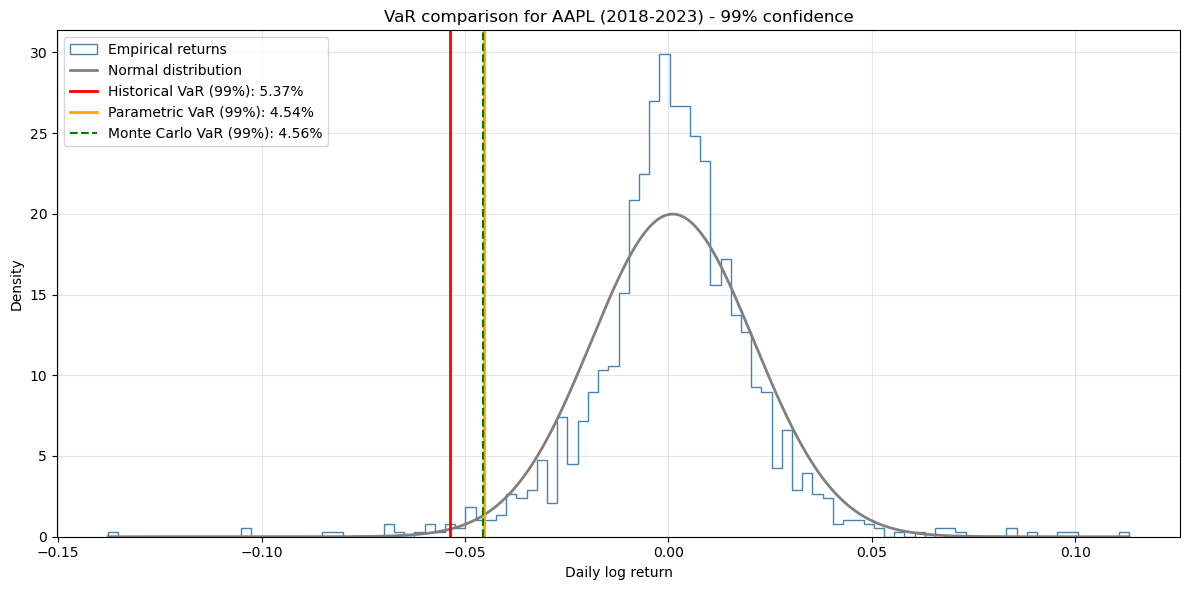


Method                           VaR
------------------------------------
Historical Simulation          5.37%
Parametric                     4.54%
Monte Carlo                    4.56%
------------------------------------
Gap (Hist - Param)             0.83%


In [11]:
VaR.plot_var_comparison(returns, var_hist, var_par, var_mc, "AAPL", 0.99,100)

The above graph is accumulating all the previous conclusions we drew for the different methods and presents them visually. They are also reported below:

- The gap between the **Historical Method** and the **Parametric Method** is $0.83\%$.

- The **Parametric Method** and the **Monte Carlo Method** are predicting almost identical values for VaR. This result is reasonable since the two methods rely on the same assumption for the data distribution.

- The gap between the **Historical Method** and the **Parametric and Monte Carlo Methods** can be justified based on the shape of the data distribution. The Gaussian assumption is not modelling accurately the tails of the data distribution, which are present and taken into account by the **Historical Method**, which relies purely on data for the VaR computation, without making any assumptions.

# Expected Shortfall analysis

Below, we are printing the Expected Shortfall value and we are comparing it with the VaR value predicted by the **Historical Method**:

In [12]:
es = VaR.expected_shortfall(returns,0.99)
print(f"Historical Simulation VaR (99%) : {var_hist*100:.2f}%")
print(f"Expected Shortfall (99%)         : {es*100:.2f}%")
print(f"\nES is {(es/var_hist - 1)*100:.1f}% larger than VaR")
print(f"On the worst 1% of days, the average loss was {es*100:.2f}%")

Historical Simulation VaR (99%) : 5.37%
Expected Shortfall (99%)         : 7.41%

ES is 37.9% larger than VaR
On the worst 1% of days, the average loss was 7.41%


**Conclusion**: The value calculated for the Expected Shortfall is $7.41\%$. The meaning of this number is that in the worst $1\%$ of days, the average loss on the investment was $7.41\%$. This value is $37.9\%$ larger than the calculated VaR value. This is mainly caused by some extreme losses that can be seen on the tails existing after the VaR predicted threshold.

Finally, we are comparing the ES value along with VaR value by visualising them graphically:

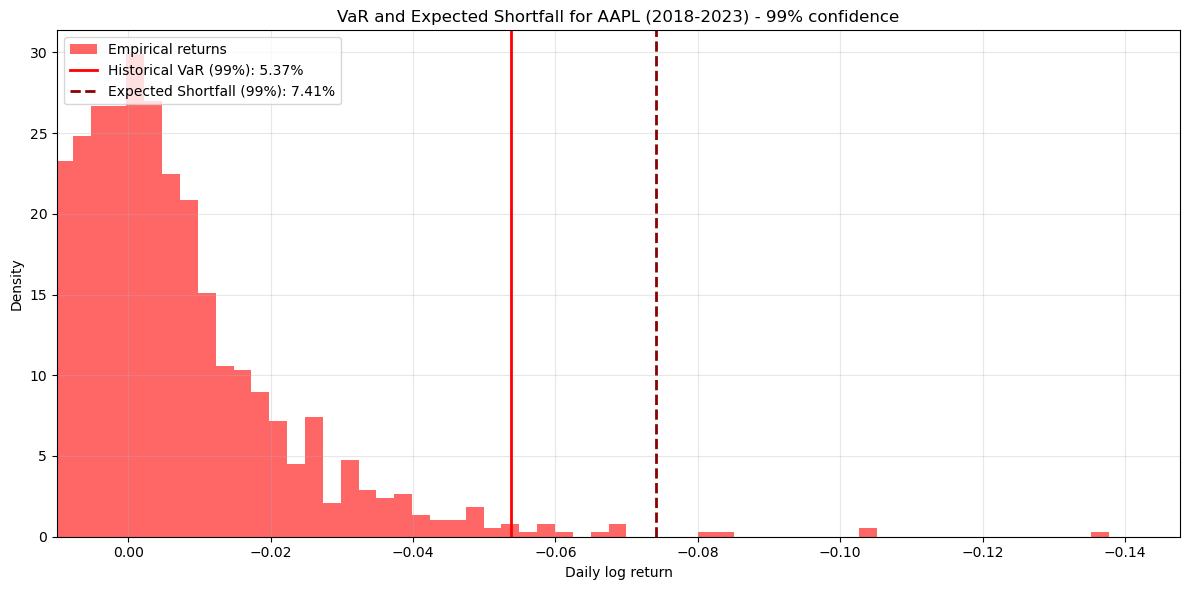


Number of days in the tails: 16
Fraction of total days: 0.010610079575596816


In [13]:
VaR.plot_expected_shortfall(returns, var_hist, es, 0.99, "AAPL", 100)

The conclusions that can be drawn from the above figures are the following:

- On the worst $1\%$ of the days, the average loss was $7.41\%$, which is $37.9\%$ larger than the VaR value predicted from the **Historical Simulation Method**. This difference is reflected in the shape of the distribution, where extreme days are present in the tails of it, accounting for  the real market crashes and sell-offs that occurred during 2018-2023.

- Since ES and VaR can differ a lot, and since VaR is only predicting a threshold for the real loss, the ES is thought to be a more reliable measure of the severity of what lies beyond this threshold.